## Install Required Packages

Install the Python libraries needed for data extraction, data manipulation, and HTML table parsing.

In [1]:
#Install required packages
!pip install pandas numpy 
!pip install lxml

## Import Libraries and Configure Warnings

Import the required libraries and suppress warning messages to keep the notebook output clean.

In [2]:
import numpy as np
import pandas as pd

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

## Define the Data Source

Specify the archived Wikipedia URL containing the GDP data of countries.

In [3]:
URL="https://web.archive.org/web/20230902185326/https://en.wikipedia.org/wiki/List_of_countries_by_GDP_%28nominal%29

We can use Pandas library to extract the required table directly as a DataFrame. Note that the required table is the third one on the website, as shown in the image below.
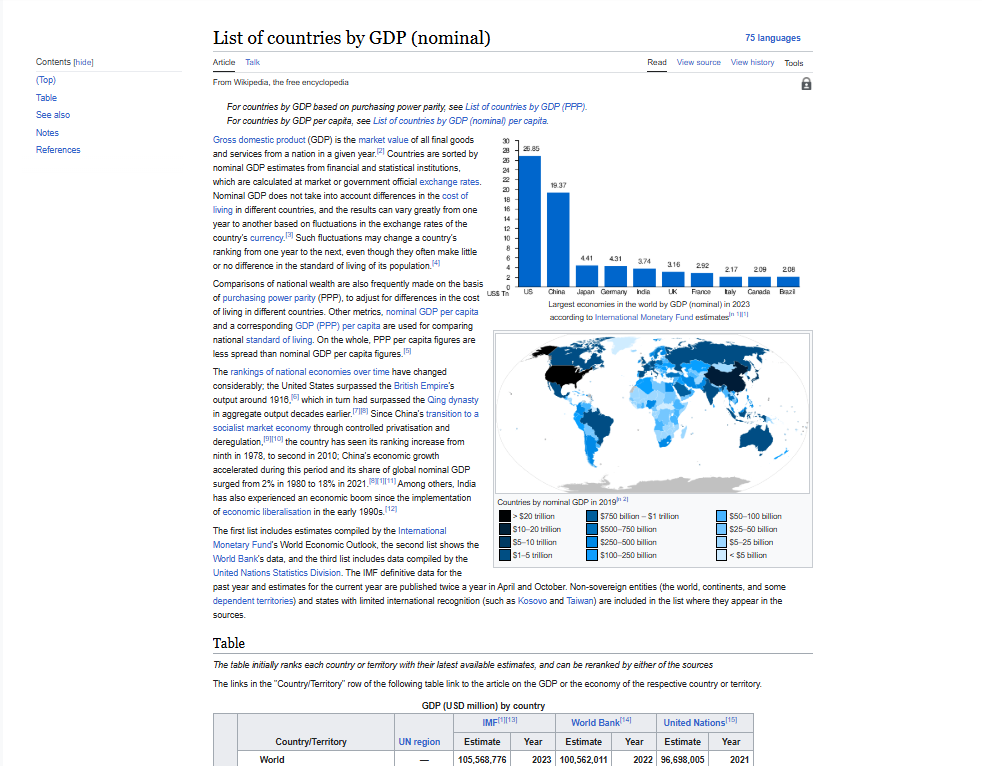

## Extract the GDP Data

Read the HTML tables from the Wikipedia page, select the required table, and retain the relevant rows and columns containing GDP information.

In [6]:
# Extract tables from webpage using Pandas. Retain table number 3 as the required dataframe.
tables = pd.read_html(URL)
df = tables[3]

# Replace the column headers with column numbers
df.columns = range(df.shape[1])

# Retain columns with index 0 and 2 (name of country and value of GDP quoted by IMF)
df = df[[0,2]]

# Retain the Rows with index 1 to 10, indicating the top 10 economies of the world.
df = df.iloc[1:11,:]

# Assign column names as "Country" and "GDP (Million USD)"
df.columns = ['Country','GDP (Million USD)']

## Transform and Format the GDP Values

Convert the GDP values to billions of USD, round them to two decimal places, and update the column name to reflect the new unit.

In [7]:
# Change the data type of the 'GDP (Million USD)' column to integer. Use astype() method.
df['GDP (Million USD)'] = df['GDP (Million USD)'].astype(int)

# Convert the GDP value in Million USD to Billion USD
df[['GDP (Million USD)']] = df[['GDP (Million USD)']]/1000

# Use numpy.round() method to round the value to 2 decimal places.
df[['GDP (Million USD)']] = np.round(df[['GDP (Million USD)']], 2)

# Rename the column header from 'GDP (Million USD)' to 'GDP (Billion USD)'
df.rename(columns = {'GDP (Million USD)' : 'GDP (Billion USD)'})

,Country,GDP (Billion USD)
1,United States,26854.60
2,China,19373.59
3,Japan,4409.74
4,Germany,4308.85
5,India,3736.88
6,United Kingdom,3158.94
7,France,2923.49
8,Italy,2169.74
9,Canada,2089.67
10,Brazil,2081.24


## Export the Dataset to a CSV File

Save the cleaned dataset as a CSV file for future analysis and use.

In [8]:
# Load the DataFrame to the CSV file named "Largest_economies.csv"
df.to_csv('./Largest_economies.csv')